In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df = pd.read_csv("../data/sales_data.csv")

X = df.drop(columns=["sales"])
Y = df["sales"]

print("Features:",X.columns.tolist())
print("X shape:",X.shape)
print("Y shape:",Y.shape)

Features: ['month', 'advertising_spend', 'discount_pct', 'num_salespeople', 'competitor_price', 'is_holiday']
X shape: (1000, 6)
Y shape: (1000,)


In [13]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (800, 6)
Test size: (200, 6)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Training models

In [15]:
models = {
    "Linear Regression":LinearRegression(),
    "Ridge":Ridge(alpha=1.0),
    "Lasso":Lasso(alpha=1.0)
}

for name,model in models.items():
    model.fit(X_train_scaled,Y_train)
    print(f"{name} trained")

Linear Regression trained
Ridge trained
Lasso trained


In [16]:
results = []

for name,model in models.items():
    Y_pred = model.predict(X_test_scaled)
    results.append({
        "model":name,
        "MAE":round(mean_absolute_error(Y_test,Y_pred),2),
        "MSE":round(mean_squared_error(Y_test,Y_pred),2),
        "RMSE":round(np.sqrt(mean_squared_error(Y_test,Y_pred)),2),
        "R2":round(r2_score(Y_test,Y_pred),4)
    })

results_df = pd.DataFrame(results)
results_df

,model,MAE,MSE,RMSE,R2
0,Linear Regression,1763.38,4843985.01,2200.91,0.9447
1,Ridge,1764.20,4842481.52,2200.56,0.9447
2,Lasso,1763.45,4843444.83,2200.78,0.9447


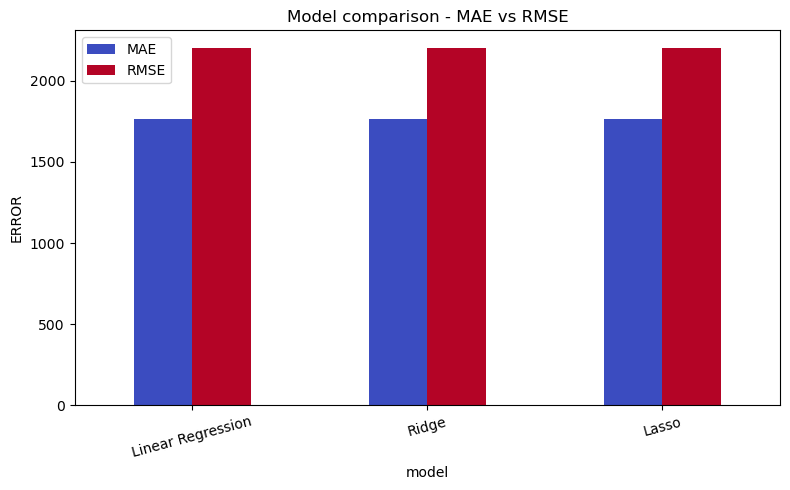

In [18]:
results_df.set_index("model")[["MAE","RMSE"]].plot(
    kind="bar",figsize=(8,5),colormap="coolwarm"
)

plt.title("Model comparison - MAE vs RMSE")
plt.ylabel("ERROR")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

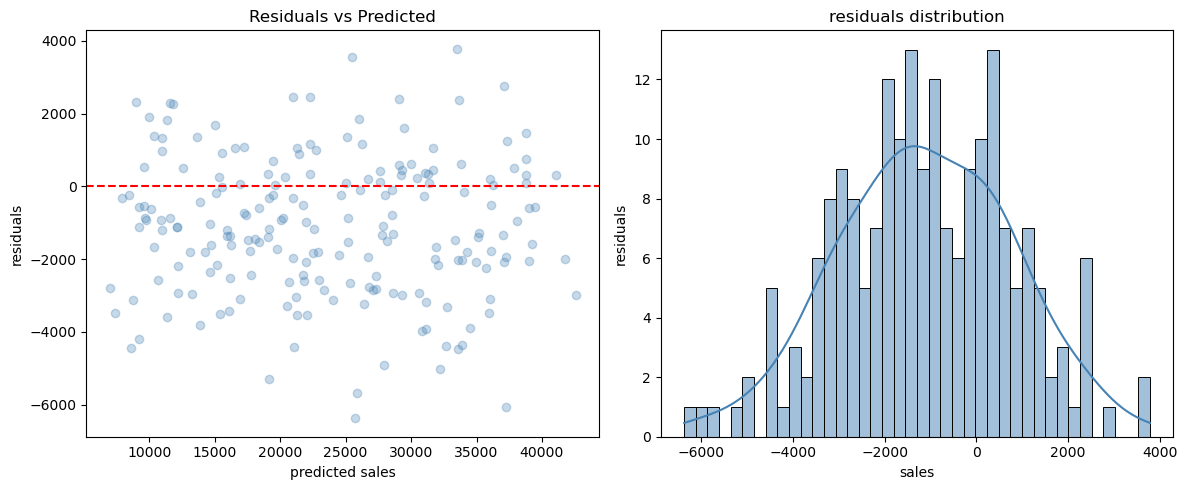

In [24]:
best_model = models["Linear Regression"]
y_pred = best_model.predict(X_test_scaled)
residuals = Y_test - y_pred

fig,axes = plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(y_pred,residuals,alpha=0.3,color="steelblue")
axes[0].axhline(0,color="red",linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("predicted sales")
axes[0].set_ylabel("residuals")


sns.histplot(residuals,bins=40,kde=True,ax=axes[1],color="steelblue")
axes[1].set_title("residuals distribution")
axes[1].set_ylabel("residuals")

plt.tight_layout()
plt.show()

In [28]:
joblib.dump(best_model, "../models/linear_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")


['../models/scaler.pkl']